# YearPredictionMSD — Deep Learning Regression with PyTorch

This case study develops a deep neural-network regression pipeline for **release-year prediction** using the UCI YearPredictionMSD dataset.

The dataset contains **515,345 songs** represented by 90 continuous timbre features: 12 timbre averages and 78 timbre-covariance features. The project follows the official UCI train/test partition, which was designed to reduce the *producer effect* by preventing songs from the same artist from appearing on both sides of the official split.

The workflow focuses on practical deep-learning engineering rather than a classical-ML baseline:

- reproducible PyTorch data pipelines;
- reusable training and evaluation loops;
- MLP architecture and training ablations;
- a custom multi-branch network;
- AdamW, dropout, BatchNorm, and initialization experiments;
- auxiliary decade classification for representation pretraining;
- frozen transfer learning and end-to-end fine-tuning;
- Optuna hyperparameter optimization;
- checkpointing and one-time evaluation on the locked official test set.

Model selection is performed exclusively on the validation set. The official test set is opened only after the final candidate has been selected.

## 1. Imports and configuration

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import copy
import gc
import random
import time
import zipfile
from dataclasses import dataclass
from typing import Dict, List, Literal, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set to True only for debugging the notebook structure quickly.
FAST_DEV_RUN = False
DEV_FRACTION = 0.10

BATCH_SIZE = 1024
NUM_WORKERS = 0
PIN_MEMORY = device.type == 'cuda'

EXPERIMENT_EPOCHS = 30 if not FAST_DEV_RUN else 3
PRETRAIN_EPOCHS = 30 if not FAST_DEV_RUN else 3
TRANSFER_EPOCHS = 30 if not FAST_DEV_RUN else 3
FINE_TUNE_EPOCHS = 30 if not FAST_DEV_RUN else 3
N_TRIALS = 12 if not FAST_DEV_RUN else 2
TRIAL_EPOCHS = 15 if not FAST_DEV_RUN else 2
FINAL_EPOCHS = 60 if not FAST_DEV_RUN else 3
EARLY_STOPPING_PATIENCE = 10 if not FAST_DEV_RUN else 2

print('PyTorch:', torch.__version__)
print('Device:', device)
print('FAST_DEV_RUN:', FAST_DEV_RUN)

PyTorch: 2.14.0+cu130
Device: cuda
FAST_DEV_RUN: False


## 2. Data acquisition

In [2]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

UCI_ZIP_URL = (
    'https://archive.ics.uci.edu/static/public/203/'
    'yearpredictionmsd.zip'
)

zip_path = DATA_DIR / 'yearpredictionmsd.zip'
txt_path = DATA_DIR / 'YearPredictionMSD.txt'

if not txt_path.exists():
    if not zip_path.exists():
        print('Downloading YearPredictionMSD from UCI...')
        urlretrieve(UCI_ZIP_URL, zip_path)

    with zipfile.ZipFile(zip_path) as zf:
        txt_members = [
            name for name in zf.namelist()
            if name.lower().endswith('.txt')
        ]
        if not txt_members:
            raise FileNotFoundError('No .txt file found in the UCI archive.')

        member = txt_members[0]
        zf.extract(member, DATA_DIR)
        extracted = DATA_DIR / member
        if extracted != txt_path:
            extracted.replace(txt_path)

print('Dataset file:', txt_path)

Dataset file: data\YearPredictionMSD.txt


## 3. Load and audit the dataset

In [3]:
column_names = (
    ['year']
    + [f'timbre_mean_{i:02d}' for i in range(1, 13)]
    + [f'timbre_cov_{i:02d}' for i in range(1, 79)]
)

df = pd.read_csv(
    txt_path,
    header=None,
    names=column_names,
)

print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
print('Exact duplicates:', int(df.duplicated().sum()))
print('Target range:', (int(df['year'].min()), int(df['year'].max())))
print('Feature count:', df.shape[1] - 1)
display(df.head())

Shape: (515345, 91)
Missing values: 0
Exact duplicates: 214
Target range: (1922, 2011)
Feature count: 90


,year,timbre_mean_01,timbre_mean_02,timbre_mean_03,timbre_mean_04,timbre_mean_05,timbre_mean_06,timbre_mean_07,timbre_mean_08,timbre_mean_09,...,timbre_cov_69,timbre_cov_70,timbre_cov_71,timbre_cov_72,timbre_cov_73,timbre_cov_74,timbre_cov_75,timbre_cov_76,timbre_cov_77,timbre_cov_78
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


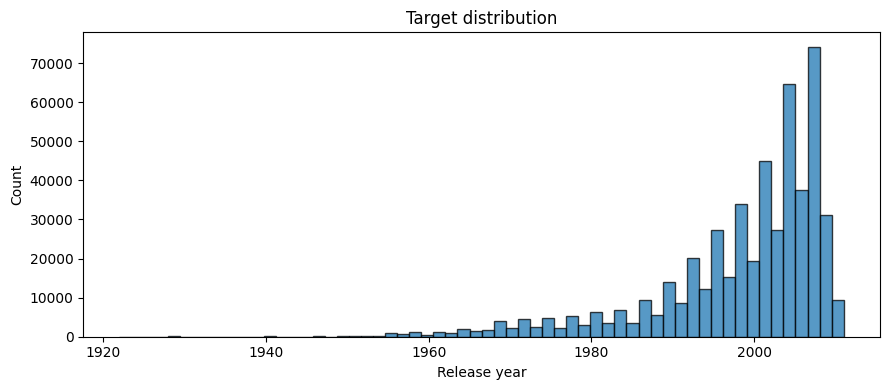

In [4]:
plt.figure(figsize=(9, 4))
plt.hist(df['year'], bins=60, edgecolor='black', alpha=0.75)
plt.xlabel('Release year')
plt.ylabel('Count')
plt.title('Target distribution')
plt.tight_layout()
plt.show()

### Data-quality observations

The loaded dataset contains **515,345 rows**, 90 numerical predictors, no missing values, and 214 exact duplicate rows. The target spans 1922–2011 and is heavily concentrated in recent decades.

The duplicate rows are retained. Their origin cannot be resolved from the benchmark matrix alone, and they represent only a very small fraction of the full dataset. More importantly, a direct feature-vector check found **no identical 90-dimensional feature vectors shared across the official train and test partitions**, so there is no direct duplicate-vector leakage across the locked split.

The strong temporal imbalance is more consequential for modeling: later sections show that the 1990s and especially the 2000s contain orders of magnitude more examples than the earliest decades. Global MAE/RMSE will therefore be dominated by the densely represented portion of the target distribution.

## 4. Official split and preprocessing

In [5]:
OFFICIAL_TRAIN_SIZE = 463_715

train_full_df = df.iloc[:OFFICIAL_TRAIN_SIZE].copy()
test_df = df.iloc[OFFICIAL_TRAIN_SIZE:].copy()

train_df, valid_df = train_test_split(
    train_full_df,
    test_size=0.10,
    random_state=RANDOM_STATE,
)

if FAST_DEV_RUN:
    train_df = train_df.sample(
        frac=DEV_FRACTION,
        random_state=RANDOM_STATE,
    )
    valid_df = valid_df.sample(
        frac=min(1.0, DEV_FRACTION * 2),
        random_state=RANDOM_STATE,
    )

feature_columns = [c for c in df.columns if c != 'year']
mean_features = feature_columns[:12]
covariance_features = feature_columns[12:]

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(
    train_df[feature_columns]
).astype(np.float32)
X_valid = x_scaler.transform(
    valid_df[feature_columns]
).astype(np.float32)
X_test = x_scaler.transform(
    test_df[feature_columns]
).astype(np.float32)

y_train = y_scaler.fit_transform(
    train_df[['year']]
).astype(np.float32)
y_valid = y_scaler.transform(
    valid_df[['year']]
).astype(np.float32)
y_test = y_scaler.transform(
    test_df[['year']]
).astype(np.float32)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_valid.shape, y_valid.shape)
print('Official test:', X_test.shape, y_test.shape)
print('Target mean/std fitted on train:', y_scaler.mean_[0], y_scaler.scale_[0])

Train: (417343, 90) (417343, 1)
Validation: (46372, 90) (46372, 1)
Official test: (51630, 90) (51630, 1)
Target mean/std fitted on train: 1998.3820694249096 10.94200046293729


In [6]:
# Check whether identical feature vectors occur in both official partitions.
# This does not replace the artist-aware rationale for the official split;
# it is only a direct duplicate-vector sanity check.
X_train_full_scaled = x_scaler.transform(
    train_full_df[feature_columns]
).astype(np.float32)

train_rows = np.ascontiguousarray(X_train_full_scaled).view(
    np.dtype((np.void, X_train_full_scaled.dtype.itemsize * X_train_full_scaled.shape[1]))
).ravel()

test_rows = np.ascontiguousarray(X_test).view(
    np.dtype((np.void, X_test.dtype.itemsize * X_test.shape[1]))
).ravel()

common_rows = np.intersect1d(train_rows, test_rows)
print('Shared feature vectors across official train/test:', len(common_rows))

del X_train_full_scaled, train_rows, test_rows, common_rows
gc.collect()

Shared feature vectors across official train/test: 0


5937

### Split and preprocessing decisions

The official test set is kept intact at **51,630 songs**. The first 463,715 official training rows are split into 417,343 training observations and 46,372 validation observations.

Both feature scaling and target scaling are fitted only on the training subset. Standardizing the target makes optimization numerically easier while preserving the original regression objective after inverse transformation.

One limitation remains: the public matrix does not include artist identifiers. The internal train/validation split is therefore random within the official training partition and cannot enforce artist-level separation. Validation may consequently be somewhat easier than the official artist-aware test set. The final test result is the stronger estimate of out-of-artist generalization.

## 5. PyTorch Dataset and DataLoaders

In [7]:
class YearPredictionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


def make_loader(dataset, batch_size, shuffle, *, seed=RANDOM_STATE):
    generator = None
    if shuffle:
        generator = torch.Generator()
        generator.manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        generator=generator,
    )


train_dataset = YearPredictionDataset(X_train, y_train)
valid_dataset = YearPredictionDataset(X_valid, y_valid)
test_dataset = YearPredictionDataset(X_test, y_test)

train_loader = make_loader(train_dataset, BATCH_SIZE, True)
valid_loader = make_loader(valid_dataset, BATCH_SIZE, False)
test_loader = make_loader(test_dataset, BATCH_SIZE, False)

X_batch, y_batch = next(iter(train_loader))
print('Batch shapes:', X_batch.shape, y_batch.shape)
print('Batch dtypes:', X_batch.dtype, y_batch.dtype)

Batch shapes: torch.Size([1024, 90]) torch.Size([1024, 1])
Batch dtypes: torch.float32 torch.float32


## 6. Reusable training utilities

In [8]:
@dataclass
class TrainResult:
    best_state: Dict
    train_loss_history: List[float]
    validation_loss_history: List[float]
    best_epoch: int


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    *,
    max_grad_norm=None,
    scheduler=None,
    scheduler_per_batch=False,
):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()

        if max_grad_norm is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        if scheduler is not None and scheduler_per_batch:
            scheduler.step()

        batch_size = len(X_batch)
        total_loss += loss.item() * batch_size
        total_examples += batch_size

    return total_loss / total_examples


@torch.no_grad()
def evaluate_mse(model, loader, device):
    model.eval()
    total_squared_error = 0.0
    total_examples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        y_pred = model(X_batch)
        squared_error = torch.sum((y_pred - y_batch) ** 2).item()

        total_squared_error += squared_error
        total_examples += y_batch.numel()

    return total_squared_error / total_examples


def fit_model(
    model,
    train_loader,
    valid_loader,
    optimizer,
    criterion,
    device,
    n_epochs,
    *,
    scheduler=None,
    scheduler_per_batch=False,
    max_grad_norm=None,
    patience=EARLY_STOPPING_PATIENCE,
    verbose=True,
):
    train_history = []
    valid_history = []
    best_validation_loss = float('inf')
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(n_epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            max_grad_norm=max_grad_norm,
            scheduler=scheduler,
            scheduler_per_batch=scheduler_per_batch,
        )

        validation_loss = evaluate_mse(
            model,
            valid_loader,
            device,
        )

        train_history.append(train_loss)
        valid_history.append(validation_loss)

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if scheduler is not None and not scheduler_per_batch:
            scheduler.step()

        if verbose:
            print(
                f'Epoch {epoch + 1:03d}/{n_epochs} | '
                f'Train MSE: {train_loss:.4f} | '
                f'Validation MSE: {validation_loss:.4f}'
            )

        if patience is not None and epochs_without_improvement >= patience:
            if verbose:
                print(f'Early stopping at epoch {epoch + 1}.')
            break

    model.load_state_dict(best_state)

    return TrainResult(
        best_state=best_state,
        train_loss_history=train_history,
        validation_loss_history=valid_history,
        best_epoch=best_epoch,
    )


def scaled_mse_to_rmse_years(mse):
    return float(np.sqrt(mse) * y_scaler.scale_[0])


@torch.no_grad()
def predict_years(model, loader, device):
    model.eval()
    predictions = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_pred = model(X_batch).cpu().numpy()

        predictions.append(y_pred)
        targets.append(y_batch.numpy())

    predictions = np.concatenate(predictions, axis=0)
    targets = np.concatenate(targets, axis=0)

    return (
        y_scaler.inverse_transform(predictions).ravel(),
        y_scaler.inverse_transform(targets).ravel(),
    )


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def plot_training_history(result, title):
    epochs = np.arange(1, len(result.train_loss_history) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, result.train_loss_history, label='Train MSE')
    plt.plot(epochs, result.validation_loss_history, label='Validation MSE')
    plt.xlabel('Epoch')
    plt.ylabel('Scaled MSE')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Model definitions

In [9]:
class RegressionMLP(nn.Module):
    def __init__(
        self,
        n_inputs,
        hidden_dims,
        activation_function: Literal['relu', 'lrelu', 'elu'] = 'relu',
        dropout_p=0.0,
        normalization: Optional[Literal['batch', 'layer']] = None,
    ):
        super().__init__()

        def get_activation(name):
            if name == 'relu':
                return nn.ReLU()
            if name == 'lrelu':
                return nn.LeakyReLU()
            if name == 'elu':
                return nn.ELU()
            raise ValueError(f'Unsupported activation: {name}')

        def get_normalization(name, n_features):
            if name is None:
                return None
            if name == 'batch':
                return nn.BatchNorm1d(n_features)
            if name == 'layer':
                return nn.LayerNorm(n_features)
            raise ValueError(f'Unsupported normalization: {name}')

        layers = []
        input_dim = n_inputs

        for output_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, output_dim))
            layers.append(get_activation(activation_function))

            norm = get_normalization(normalization, output_dim)
            if norm is not None:
                layers.append(norm)

            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))

            input_dim = output_dim

        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, X):
        return self.mlp(X)


class MultiBranchRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.mean_branch = nn.Sequential(
            nn.Linear(12, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )

        self.cov_branch = nn.Sequential(
            nn.Linear(78, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )

        self.regression_head = nn.Sequential(
            nn.Linear(48, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, X):
        mean_repr = self.mean_branch(X[:, :12])
        cov_repr = self.cov_branch(X[:, 12:])
        combined = torch.cat((mean_repr, cov_repr), dim=1)
        return self.regression_head(combined)


def initialize_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias)

## 8. Baseline MLP and selected training ablations

In [10]:
criterion = nn.MSELoss()
experiment_rows = []
experiment_artifacts = {}


def run_regression_experiment(
    name,
    model,
    optimizer,
    *,
    n_epochs=EXPERIMENT_EPOCHS,
    scheduler=None,
    scheduler_per_batch=False,
    max_grad_norm=None,
):
    start = time.perf_counter()

    result = fit_model(
        model,
        train_loader,
        valid_loader,
        optimizer,
        criterion,
        device,
        n_epochs=n_epochs,
        scheduler=scheduler,
        scheduler_per_batch=scheduler_per_batch,
        max_grad_norm=max_grad_norm,
    )

    elapsed = time.perf_counter() - start
    val_mse = min(result.validation_loss_history)
    val_rmse_years = scaled_mse_to_rmse_years(val_mse)

    row = {
        'experiment': name,
        'parameters': count_parameters(model),
        'best_epoch': result.best_epoch,
        'validation_mse': val_mse,
        'validation_rmse_years': val_rmse_years,
        'training_seconds': elapsed,
    }

    experiment_rows.append(row)
    experiment_artifacts[name] = {
        'model': copy.deepcopy(model).cpu(),
        'result': result,
    }

    print(pd.DataFrame([row]).to_string(index=False))
    return model, result

Epoch 001/30 | Train MSE: 0.9341 | Validation MSE: 0.8474
Epoch 002/30 | Train MSE: 0.8015 | Validation MSE: 0.7585
Epoch 003/30 | Train MSE: 0.7389 | Validation MSE: 0.7173
Epoch 004/30 | Train MSE: 0.7102 | Validation MSE: 0.6985
Epoch 005/30 | Train MSE: 0.6954 | Validation MSE: 0.6872
Epoch 006/30 | Train MSE: 0.6856 | Validation MSE: 0.6788
Epoch 007/30 | Train MSE: 0.6779 | Validation MSE: 0.6723
Epoch 008/30 | Train MSE: 0.6716 | Validation MSE: 0.6672
Epoch 009/30 | Train MSE: 0.6663 | Validation MSE: 0.6626
Epoch 010/30 | Train MSE: 0.6617 | Validation MSE: 0.6590
Epoch 011/30 | Train MSE: 0.6576 | Validation MSE: 0.6555
Epoch 012/30 | Train MSE: 0.6539 | Validation MSE: 0.6523
Epoch 013/30 | Train MSE: 0.6506 | Validation MSE: 0.6500
Epoch 014/30 | Train MSE: 0.6476 | Validation MSE: 0.6479
Epoch 015/30 | Train MSE: 0.6448 | Validation MSE: 0.6462
Epoch 016/30 | Train MSE: 0.6422 | Validation MSE: 0.6435
Epoch 017/30 | Train MSE: 0.6399 | Validation MSE: 0.6417
Epoch 018/30 |

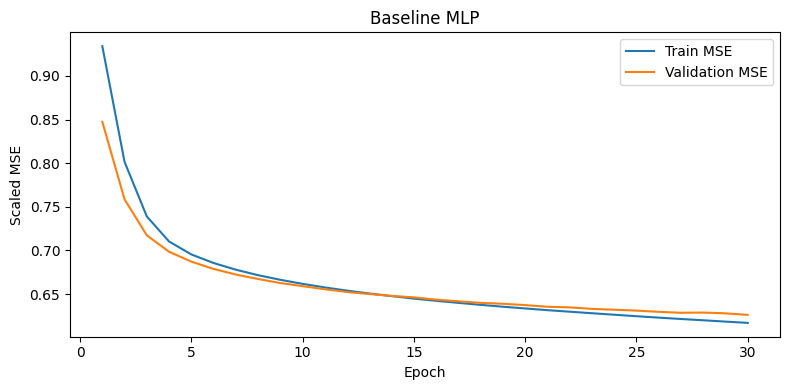

In [11]:
# Baseline: the same core architecture used in the study notebook.
torch.manual_seed(RANDOM_STATE)
baseline_model = RegressionMLP(
    n_inputs=90,
    hidden_dims=[256, 128, 64],
    activation_function='relu',
).to(device)

baseline_optimizer = torch.optim.SGD(
    baseline_model.parameters(),
    lr=0.01,
)

baseline_model, baseline_result = run_regression_experiment(
    'Baseline MLP — SGD',
    baseline_model,
    baseline_optimizer,
)

plot_training_history(baseline_result, 'Baseline MLP')

In [12]:
# Regularized AdamW model with He initialization.
torch.manual_seed(RANDOM_STATE)
adamw_model = RegressionMLP(
    n_inputs=90,
    hidden_dims=[256, 128, 64],
    activation_function='relu',
    dropout_p=0.20,
).to(device)
adamw_model.apply(initialize_weights)

adamw_optimizer = torch.optim.AdamW(
    adamw_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3,
)

adamw_model, adamw_result = run_regression_experiment(
    'He init + AdamW + Dropout',
    adamw_model,
    adamw_optimizer,
)

Epoch 001/30 | Train MSE: 0.8542 | Validation MSE: 0.7091
Epoch 002/30 | Train MSE: 0.7138 | Validation MSE: 0.6719
Epoch 003/30 | Train MSE: 0.6838 | Validation MSE: 0.6514
Epoch 004/30 | Train MSE: 0.6677 | Validation MSE: 0.6392
Epoch 005/30 | Train MSE: 0.6563 | Validation MSE: 0.6318
Epoch 006/30 | Train MSE: 0.6475 | Validation MSE: 0.6315
Epoch 007/30 | Train MSE: 0.6401 | Validation MSE: 0.6239
Epoch 008/30 | Train MSE: 0.6345 | Validation MSE: 0.6209
Epoch 009/30 | Train MSE: 0.6286 | Validation MSE: 0.6175
Epoch 010/30 | Train MSE: 0.6240 | Validation MSE: 0.6173
Epoch 011/30 | Train MSE: 0.6187 | Validation MSE: 0.6108
Epoch 012/30 | Train MSE: 0.6132 | Validation MSE: 0.6096
Epoch 013/30 | Train MSE: 0.6088 | Validation MSE: 0.6067
Epoch 014/30 | Train MSE: 0.6023 | Validation MSE: 0.6082
Epoch 015/30 | Train MSE: 0.6003 | Validation MSE: 0.6025
Epoch 016/30 | Train MSE: 0.5960 | Validation MSE: 0.6048
Epoch 017/30 | Train MSE: 0.5919 | Validation MSE: 0.6009
Epoch 018/30 |

In [13]:
# Batch-normalized variant.
torch.manual_seed(RANDOM_STATE)
batchnorm_model = RegressionMLP(
    n_inputs=90,
    hidden_dims=[256, 128, 64],
    activation_function='relu',
    dropout_p=0.20,
    normalization='batch',
).to(device)
batchnorm_model.apply(initialize_weights)

batchnorm_optimizer = torch.optim.AdamW(
    batchnorm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3,
)

batchnorm_model, batchnorm_result = run_regression_experiment(
    'BatchNorm + AdamW + Dropout',
    batchnorm_model,
    batchnorm_optimizer,
)

Epoch 001/30 | Train MSE: 1.0214 | Validation MSE: 0.6845
Epoch 002/30 | Train MSE: 0.7142 | Validation MSE: 0.6589
Epoch 003/30 | Train MSE: 0.6793 | Validation MSE: 0.6449
Epoch 004/30 | Train MSE: 0.6645 | Validation MSE: 0.6359
Epoch 005/30 | Train MSE: 0.6542 | Validation MSE: 0.6309
Epoch 006/30 | Train MSE: 0.6470 | Validation MSE: 0.6237
Epoch 007/30 | Train MSE: 0.6402 | Validation MSE: 0.6196
Epoch 008/30 | Train MSE: 0.6346 | Validation MSE: 0.6165
Epoch 009/30 | Train MSE: 0.6296 | Validation MSE: 0.6121
Epoch 010/30 | Train MSE: 0.6242 | Validation MSE: 0.6098
Epoch 011/30 | Train MSE: 0.6198 | Validation MSE: 0.6073
Epoch 012/30 | Train MSE: 0.6158 | Validation MSE: 0.6069
Epoch 013/30 | Train MSE: 0.6119 | Validation MSE: 0.6029
Epoch 014/30 | Train MSE: 0.6082 | Validation MSE: 0.6014
Epoch 015/30 | Train MSE: 0.6046 | Validation MSE: 0.5983
Epoch 016/30 | Train MSE: 0.6008 | Validation MSE: 0.5969
Epoch 017/30 | Train MSE: 0.5979 | Validation MSE: 0.5957
Epoch 018/30 |

In [14]:
# Custom two-branch architecture for timbre means and covariance features.
torch.manual_seed(RANDOM_STATE)
multibranch_model = MultiBranchRegressor().to(device)
multibranch_model.apply(initialize_weights)

multibranch_optimizer = torch.optim.AdamW(
    multibranch_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3,
)

multibranch_model, multibranch_result = run_regression_experiment(
    'Multi-branch MLP',
    multibranch_model,
    multibranch_optimizer,
)

Epoch 001/30 | Train MSE: 0.7778 | Validation MSE: 0.6899
Epoch 002/30 | Train MSE: 0.6746 | Validation MSE: 0.6613
Epoch 003/30 | Train MSE: 0.6497 | Validation MSE: 0.6504
Epoch 004/30 | Train MSE: 0.6358 | Validation MSE: 0.6416
Epoch 005/30 | Train MSE: 0.6259 | Validation MSE: 0.6398
Epoch 006/30 | Train MSE: 0.6166 | Validation MSE: 0.6323
Epoch 007/30 | Train MSE: 0.6084 | Validation MSE: 0.6308
Epoch 008/30 | Train MSE: 0.6014 | Validation MSE: 0.6273
Epoch 009/30 | Train MSE: 0.5948 | Validation MSE: 0.6293
Epoch 010/30 | Train MSE: 0.5873 | Validation MSE: 0.6267
Epoch 011/30 | Train MSE: 0.5807 | Validation MSE: 0.6294
Epoch 012/30 | Train MSE: 0.5744 | Validation MSE: 0.6296
Epoch 013/30 | Train MSE: 0.5687 | Validation MSE: 0.6266
Epoch 014/30 | Train MSE: 0.5637 | Validation MSE: 0.6288
Epoch 015/30 | Train MSE: 0.5582 | Validation MSE: 0.6316
Epoch 016/30 | Train MSE: 0.5535 | Validation MSE: 0.6241
Epoch 017/30 | Train MSE: 0.5478 | Validation MSE: 0.6301
Epoch 018/30 |

In [15]:
experiment_summary = (
    pd.DataFrame(experiment_rows)
    .sort_values('validation_rmse_years')
    .reset_index(drop=True)
)

display(experiment_summary)

,experiment,parameters,best_epoch,validation_mse,validation_rmse_years,training_seconds
0,BatchNorm + AdamW + Dropout,65409,30,0.585784,8.374624,199.082378
1,He init + AdamW + Dropout,64513,29,0.592798,8.424618,195.085585
2,Multi-branch MLP,26641,16,0.624087,8.644091,171.532660
3,Baseline MLP — SGD,64513,30,0.626107,8.658066,171.114638


### Training-ablation analysis

The baseline `[256, 128, 64]` MLP trained with plain SGD reached a validation RMSE of **8.66 years**. Replacing the optimization recipe with He initialization, AdamW, and dropout reduced RMSE to **8.42 years**. Adding BatchNorm to that configuration produced the best retained ablation result at **8.37 years**, roughly a 3.3% RMSE reduction relative to the SGD baseline.

The custom multi-branch model, which processes the 12 timbre-average features separately from the 78 covariance features, used only **26,641 parameters** versus roughly 64.5k in the baseline. Its validation RMSE was **8.64 years**: almost identical to the baseline despite using substantially fewer parameters, but without a generalization advantage.

The main practical finding from these retained ablations is that the training recipe mattered more than manually separating the two feature groups. AdamW, dropout, and normalization produced a larger gain than the custom feature-branch architecture.

## 9. Auxiliary decade pretraining

In [16]:
train_decades = (train_df['year'] // 10 * 10).astype(int)
valid_decades = (valid_df['year'] // 10 * 10).astype(int)

decade_classes = np.sort(train_decades.unique())
decade_to_idx = {
    decade: idx
    for idx, decade in enumerate(decade_classes)
}

y_train_decade = train_decades.map(decade_to_idx)
y_valid_decade = valid_decades.map(decade_to_idx)

if y_valid_decade.isna().any():
    unseen_decades = sorted(valid_decades[y_valid_decade.isna()].unique())
    raise ValueError(f'Validation contains unseen decades: {unseen_decades}')

y_train_decade = y_train_decade.to_numpy(dtype=np.int64)
y_valid_decade = y_valid_decade.to_numpy(dtype=np.int64)

class_counts = pd.DataFrame({
    'decade': decade_classes,
    'train_count': train_decades.value_counts().reindex(decade_classes, fill_value=0).to_numpy(),
    'valid_count': valid_decades.value_counts().reindex(decade_classes, fill_value=0).to_numpy(),
})

print('Decade classes:', len(decade_classes))
display(class_counts)

Decade classes: 10


,decade,train_count,valid_count
0,1920,181,23
1,1930,216,23
2,1940,262,33
3,1950,2565,262
4,1960,9505,1068
5,1970,20141,2208
6,1980,33812,3801
7,1990,101046,11087
8,2000,242066,27052
9,2010,7549,815


In [17]:
decade_train_dataset = TensorDataset(
    torch.as_tensor(X_train, dtype=torch.float32),
    torch.as_tensor(y_train_decade, dtype=torch.long),
)
decade_valid_dataset = TensorDataset(
    torch.as_tensor(X_valid, dtype=torch.float32),
    torch.as_tensor(y_valid_decade, dtype=torch.long),
)

decade_train_loader = make_loader(decade_train_dataset, BATCH_SIZE, True)
decade_valid_loader = make_loader(decade_valid_dataset, BATCH_SIZE, False)


class AudioFeatureExtractor(nn.Module):
    def __init__(self, n_inputs=90, representation_dim=64):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_inputs, 256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, representation_dim),
            nn.ReLU(),
        )

    def forward(self, X):
        return self.network(X)


class DecadeClassifier(nn.Module):
    def __init__(self, feature_extractor, representation_dim, n_classes):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.classifier = nn.Linear(representation_dim, n_classes)

    def forward(self, X):
        return self.classifier(self.feature_extractor(X))

In [18]:
@torch.no_grad()
def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        batch_size = len(X_batch)

        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples


def fit_classifier(model, train_loader, valid_loader, optimizer, criterion, n_epochs, patience):
    best_loss = float('inf')
    best_state = None
    best_epoch = 0
    no_improvement = 0
    history = []

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        total_examples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            batch_size = len(X_batch)
            total_loss += loss.item() * batch_size
            total_examples += batch_size

        train_loss = total_loss / total_examples
        val_loss, val_accuracy = evaluate_classifier(
            model, valid_loader, criterion, device
        )
        history.append((train_loss, val_loss, val_accuracy))

        print(
            f'Epoch {epoch + 1:03d}/{n_epochs} | '
            f'Train CE: {train_loss:.4f} | '
            f'Validation CE: {val_loss:.4f} | '
            f'Validation accuracy: {val_accuracy:.4f}'
        )

        if val_loss < best_loss:
            best_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
            no_improvement = 0
        else:
            no_improvement += 1

        if no_improvement >= patience:
            print(f'Early stopping at epoch {epoch + 1}.')
            break

    model.load_state_dict(best_state)
    return best_loss, best_epoch, pd.DataFrame(
        history,
        columns=['train_loss', 'validation_loss', 'validation_accuracy'],
    )

In [19]:
REPRESENTATION_DIM = 64

torch.manual_seed(RANDOM_STATE)
pretrain_extractor = AudioFeatureExtractor(
    n_inputs=90,
    representation_dim=REPRESENTATION_DIM,
)

decade_model = DecadeClassifier(
    feature_extractor=pretrain_extractor,
    representation_dim=REPRESENTATION_DIM,
    n_classes=len(decade_classes),
).to(device)

decade_criterion = nn.CrossEntropyLoss()
decade_optimizer = torch.optim.AdamW(
    decade_model.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

pretrain_best_loss, pretrain_best_epoch, pretrain_history = fit_classifier(
    decade_model,
    decade_train_loader,
    decade_valid_loader,
    decade_optimizer,
    decade_criterion,
    PRETRAIN_EPOCHS,
    EARLY_STOPPING_PATIENCE,
)

pretrained_feature_extractor = copy.deepcopy(
    decade_model.feature_extractor
).cpu()

print('Best pretraining epoch:', pretrain_best_epoch)
print('Best validation CE:', round(pretrain_best_loss, 6))
print('Best validation accuracy:', round(pretrain_history['validation_accuracy'].max(), 4))

Epoch 001/30 | Train CE: 1.0680 | Validation CE: 0.9494 | Validation accuracy: 0.6444
Epoch 002/30 | Train CE: 0.9549 | Validation CE: 0.9245 | Validation accuracy: 0.6502
Epoch 003/30 | Train CE: 0.9373 | Validation CE: 0.9129 | Validation accuracy: 0.6538
Epoch 004/30 | Train CE: 0.9260 | Validation CE: 0.9100 | Validation accuracy: 0.6546
Epoch 005/30 | Train CE: 0.9181 | Validation CE: 0.8999 | Validation accuracy: 0.6572
Epoch 006/30 | Train CE: 0.9120 | Validation CE: 0.8966 | Validation accuracy: 0.6572
Epoch 007/30 | Train CE: 0.9067 | Validation CE: 0.8937 | Validation accuracy: 0.6588
Epoch 008/30 | Train CE: 0.9021 | Validation CE: 0.8896 | Validation accuracy: 0.6581
Epoch 009/30 | Train CE: 0.8982 | Validation CE: 0.8880 | Validation accuracy: 0.6591
Epoch 010/30 | Train CE: 0.8948 | Validation CE: 0.8861 | Validation accuracy: 0.6612
Epoch 011/30 | Train CE: 0.8924 | Validation CE: 0.8841 | Validation accuracy: 0.6621
Epoch 012/30 | Train CE: 0.8895 | Validation CE: 0.884

### Auxiliary pretraining signal

The auxiliary decade classifier reached about **66.5% validation accuracy** across ten decade classes.

This number should not be interpreted as balanced multiclass performance: the auxiliary target is highly imbalanced. In the training subset, the 2000s alone contain more than 242k songs, while the earliest decades contain only a few hundred examples. The role of this task is therefore not to build a production decade classifier, but to force the feature extractor to learn a coarse temporal representation before year regression.

## 10. Transfer learning and fine-tuning

In [20]:
class YearRegressorFromPretrained(nn.Module):
    def __init__(self, feature_extractor, representation_dim=64):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.regression_head = nn.Linear(representation_dim, 1)

    def forward(self, X):
        representation = self.feature_extractor(X)
        return self.regression_head(representation)


def transfer_result_row(name, result):
    best_mse = min(result.validation_loss_history)
    return {
        'model': name,
        'best_epoch': result.best_epoch,
        'validation_mse': best_mse,
        'validation_rmse_years': scaled_mse_to_rmse_years(best_mse),
    }

In [21]:
# Fair scratch reference using the same extractor/head architecture.
torch.manual_seed(RANDOM_STATE)
scratch_transfer_model = YearRegressorFromPretrained(
    AudioFeatureExtractor(90, REPRESENTATION_DIM),
    REPRESENTATION_DIM,
).to(device)

scratch_optimizer = torch.optim.AdamW(
    scratch_transfer_model.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

scratch_transfer_result = fit_model(
    scratch_transfer_model,
    train_loader,
    valid_loader,
    scratch_optimizer,
    criterion,
    device,
    TRANSFER_EPOCHS,
)

Epoch 001/30 | Train MSE: 0.6973 | Validation MSE: 0.6356
Epoch 002/30 | Train MSE: 0.6436 | Validation MSE: 0.6225
Epoch 003/30 | Train MSE: 0.6301 | Validation MSE: 0.6155
Epoch 004/30 | Train MSE: 0.6209 | Validation MSE: 0.6114
Epoch 005/30 | Train MSE: 0.6136 | Validation MSE: 0.6049
Epoch 006/30 | Train MSE: 0.6067 | Validation MSE: 0.6011
Epoch 007/30 | Train MSE: 0.6018 | Validation MSE: 0.5986
Epoch 008/30 | Train MSE: 0.5962 | Validation MSE: 0.5982
Epoch 009/30 | Train MSE: 0.5918 | Validation MSE: 0.5947
Epoch 010/30 | Train MSE: 0.5869 | Validation MSE: 0.5976
Epoch 011/30 | Train MSE: 0.5822 | Validation MSE: 0.5966
Epoch 012/30 | Train MSE: 0.5795 | Validation MSE: 0.5922
Epoch 013/30 | Train MSE: 0.5750 | Validation MSE: 0.5904
Epoch 014/30 | Train MSE: 0.5706 | Validation MSE: 0.5904
Epoch 015/30 | Train MSE: 0.5676 | Validation MSE: 0.5905
Epoch 016/30 | Train MSE: 0.5644 | Validation MSE: 0.5928
Epoch 017/30 | Train MSE: 0.5617 | Validation MSE: 0.5909
Epoch 018/30 |

In [22]:
# Frozen pretrained extractor: train only the new regression head.
frozen_extractor = copy.deepcopy(pretrained_feature_extractor).to(device)
frozen_transfer_model = YearRegressorFromPretrained(
    frozen_extractor,
    REPRESENTATION_DIM,
).to(device)

for parameter in frozen_transfer_model.feature_extractor.parameters():
    parameter.requires_grad = False

frozen_optimizer = torch.optim.AdamW(
    frozen_transfer_model.regression_head.parameters(),
    lr=1e-3,
    weight_decay=1e-2,
)

frozen_transfer_result = fit_model(
    frozen_transfer_model,
    train_loader,
    valid_loader,
    frozen_optimizer,
    criterion,
    device,
    TRANSFER_EPOCHS,
)

Epoch 001/30 | Train MSE: 0.6798 | Validation MSE: 0.6256
Epoch 002/30 | Train MSE: 0.6227 | Validation MSE: 0.6174
Epoch 003/30 | Train MSE: 0.6163 | Validation MSE: 0.6160
Epoch 004/30 | Train MSE: 0.6157 | Validation MSE: 0.6147
Epoch 005/30 | Train MSE: 0.6145 | Validation MSE: 0.6139
Epoch 006/30 | Train MSE: 0.6145 | Validation MSE: 0.6140
Epoch 007/30 | Train MSE: 0.6141 | Validation MSE: 0.6141
Epoch 008/30 | Train MSE: 0.6130 | Validation MSE: 0.6133
Epoch 009/30 | Train MSE: 0.6124 | Validation MSE: 0.6133
Epoch 010/30 | Train MSE: 0.6133 | Validation MSE: 0.6130
Epoch 011/30 | Train MSE: 0.6126 | Validation MSE: 0.6134
Epoch 012/30 | Train MSE: 0.6140 | Validation MSE: 0.6141
Epoch 013/30 | Train MSE: 0.6135 | Validation MSE: 0.6136
Epoch 014/30 | Train MSE: 0.6135 | Validation MSE: 0.6138
Epoch 015/30 | Train MSE: 0.6125 | Validation MSE: 0.6135
Epoch 016/30 | Train MSE: 0.6136 | Validation MSE: 0.6142
Epoch 017/30 | Train MSE: 0.6131 | Validation MSE: 0.6132
Epoch 018/30 |

In [23]:
# Fine-tune the best frozen-transfer checkpoint at a lower learning rate.
fine_tuned_model = copy.deepcopy(frozen_transfer_model)
for parameter in fine_tuned_model.feature_extractor.parameters():
    parameter.requires_grad = True

fine_tune_optimizer = torch.optim.AdamW(
    fine_tuned_model.parameters(),
    lr=1e-4,
    weight_decay=1e-2,
)

fine_tune_result = fit_model(
    fine_tuned_model,
    train_loader,
    valid_loader,
    fine_tune_optimizer,
    criterion,
    device,
    FINE_TUNE_EPOCHS,
)

transfer_comparison = pd.DataFrame([
    transfer_result_row('Regression from scratch', scratch_transfer_result),
    transfer_result_row('Frozen auxiliary pretraining', frozen_transfer_result),
    transfer_result_row('Fine-tuned auxiliary pretraining', fine_tune_result),
]).sort_values('validation_rmse_years').reset_index(drop=True)

display(transfer_comparison)

Epoch 001/30 | Train MSE: 0.6025 | Validation MSE: 0.5988
Epoch 002/30 | Train MSE: 0.5919 | Validation MSE: 0.5957
Epoch 003/30 | Train MSE: 0.5867 | Validation MSE: 0.5936
Epoch 004/30 | Train MSE: 0.5835 | Validation MSE: 0.5922
Epoch 005/30 | Train MSE: 0.5812 | Validation MSE: 0.5907
Epoch 006/30 | Train MSE: 0.5780 | Validation MSE: 0.5900
Epoch 007/30 | Train MSE: 0.5772 | Validation MSE: 0.5889
Epoch 008/30 | Train MSE: 0.5739 | Validation MSE: 0.5884
Epoch 009/30 | Train MSE: 0.5738 | Validation MSE: 0.5867
Epoch 010/30 | Train MSE: 0.5725 | Validation MSE: 0.5868
Epoch 011/30 | Train MSE: 0.5697 | Validation MSE: 0.5859
Epoch 012/30 | Train MSE: 0.5693 | Validation MSE: 0.5856
Epoch 013/30 | Train MSE: 0.5687 | Validation MSE: 0.5847
Epoch 014/30 | Train MSE: 0.5668 | Validation MSE: 0.5845
Epoch 015/30 | Train MSE: 0.5659 | Validation MSE: 0.5845
Epoch 016/30 | Train MSE: 0.5637 | Validation MSE: 0.5836
Epoch 017/30 | Train MSE: 0.5634 | Validation MSE: 0.5832
Epoch 018/30 |

,model,best_epoch,validation_mse,validation_rmse_years
0,Fine-tuned auxiliary pretraining,30,0.580401,8.336060
1,Regression from scratch,27,0.586570,8.380246
2,Frozen auxiliary pretraining,23,0.612404,8.562801


### Transfer-learning analysis

Freezing the decade-pretrained feature extractor and training only a new regression head performed worse than training the same architecture from scratch: **8.56 vs. 8.38 years validation RMSE**. The pretrained representation was therefore not sufficiently aligned with exact-year regression when kept fixed.

The result changed after unfreezing the extractor and fine-tuning the full network with a smaller learning rate. Validation RMSE improved to **8.34 years**, about a 0.5% relative improvement over the same architecture trained from scratch.

This is a useful distinction: the auxiliary task did not provide a ready-made representation that could simply be frozen, but it did provide a better initialization once the representation was allowed to adapt to the regression objective.

## 11. Hyperparameter optimization with Optuna

In [24]:
def build_hidden_dims(base_width, depth):
    return [
        max(base_width // (2 ** i), 32)
        for i in range(depth)
    ]


base_train_dataset = train_loader.dataset
base_valid_dataset = valid_loader.dataset
search_criterion = nn.MSELoss()


def objective(trial):
    learning_rate = trial.suggest_float('learning_rate', 2e-4, 3e-3, log=True)
    depth = trial.suggest_int('depth', 2, 4)
    base_width = trial.suggest_categorical('base_width', [128, 256, 512])
    dropout_p = trial.suggest_float('dropout_p', 0.0, 0.35, step=0.05)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 3e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])

    hidden_dims = build_hidden_dims(base_width, depth)

    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

    trial_train_loader = make_loader(
        base_train_dataset,
        batch_size,
        True,
        seed=RANDOM_STATE,
    )
    trial_valid_loader = make_loader(
        base_valid_dataset,
        batch_size,
        False,
    )

    model = RegressionMLP(
        90,
        hidden_dims,
        'relu',
        dropout_p=dropout_p,
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    best_val_mse = float('inf')

    for epoch in range(TRIAL_EPOCHS):
        train_one_epoch(
            model,
            trial_train_loader,
            optimizer,
            search_criterion,
            device,
        )

        val_mse = evaluate_mse(model, trial_valid_loader, device)
        best_val_mse = min(best_val_mse, val_mse)

        trial.report(val_mse, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    trial.set_user_attr('hidden_dims', hidden_dims)

    del model, optimizer, trial_train_loader, trial_valid_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val_mse


optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(
    n_startup_trials=min(5, N_TRIALS),
    n_warmup_steps=min(5, TRIAL_EPOCHS - 1),
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
)
study.optimize(objective, n_trials=N_TRIALS)

print('Best validation MSE:', study.best_value)
print('Best hyperparameters:')
for name, value in study.best_params.items():
    print(f'  {name}: {value}')
print('Hidden dims:', study.best_trial.user_attrs['hidden_dims'])

display(
    study.trials_dataframe()
    .sort_values('value', na_position='last')
    .head(10)
)

Best validation MSE: 0.5869748696233676
Best hyperparameters:
  learning_rate: 0.0003746503800161527
  depth: 4
  base_width: 512
  dropout_p: 0.25
  weight_decay: 0.00017783824742109217
  batch_size: 512
Hidden dims: [512, 256, 128, 64]


,number,value,datetime_start,datetime_complete,duration,params_base_width,params_batch_size,params_depth,params_dropout_p,params_learning_rate,params_weight_decay,user_attrs_hidden_dims,system_attrs_tpe:relative_params:0,state
11,11,0.586975,2026-09-26 01:52:01.235558,2026-09-26 01:54:06.489694,0 days 00:02:05.254136,512,512,4,0.25,0.000375,0.000178,"[512, 256, 128, 64]","{""base_width"": 512, ""batch_size"": 512, ""depth""...",COMPLETE
9,9,0.588186,2026-09-26 01:47:52.206684,2026-09-26 01:49:56.787428,0 days 00:02:04.580744,512,512,4,0.15,0.000276,0.000657,"[512, 256, 128, 64]",NaN,COMPLETE
10,10,0.589394,2026-09-26 01:49:56.787428,2026-09-26 01:52:01.235558,0 days 00:02:04.448130,512,512,4,0.05,0.000431,0.002939,"[512, 256, 128, 64]","{""base_width"": 512, ""batch_size"": 512, ""depth""...",COMPLETE
2,2,0.592162,2026-09-26 01:39:17.492636,2026-09-26 01:41:03.997710,0 days 00:01:46.505074,512,1024,2,0.30,0.001049,0.000049,"[512, 256]",NaN,COMPLETE
3,3,0.593071,2026-09-26 01:41:03.997710,2026-09-26 01:42:52.282561,0 days 00:01:48.284851,512,1024,2,0.30,0.001036,0.000115,"[512, 256]",NaN,COMPLETE
4,4,0.600771,2026-09-26 01:42:52.282561,2026-09-26 01:44:32.814680,0 days 00:01:40.532119,256,1024,3,0.25,0.000278,0.000121,"[256, 128, 64]",NaN,COMPLETE
0,0,0.603280,2026-09-26 01:35:11.583630,2026-09-26 01:37:16.109040,0 days 00:02:04.525410,128,512,4,0.05,0.000551,0.000016,"[128, 64, 32, 32]",NaN,COMPLETE
8,8,0.604069,2026-09-26 01:46:19.573271,2026-09-26 01:47:52.205685,0 days 00:01:32.632414,128,1024,3,0.10,0.002071,0.003443,NaN,NaN,PRUNED
1,1,0.606657,2026-09-26 01:37:16.109040,2026-09-26 01:39:17.492636,0 days 00:02:01.383596,128,512,4,0.05,0.000211,0.000114,"[128, 64, 32, 32]",NaN,COMPLETE
7,7,0.610059,2026-09-26 01:45:44.209975,2026-09-26 01:46:19.573271,0 days 00:00:35.363296,256,1024,2,0.25,0.001619,0.004806,NaN,NaN,PRUNED


### Hyperparameter-search result

Optuna searched learning rate, depth, base width, dropout, weight decay, and batch size using the validation set only.

The best trial selected a four-layer MLP with hidden widths `[512, 256, 128, 64]`, dropout of 0.25, batch size 512, learning rate of approximately `3.75e-4`, and weight decay of approximately `1.78e-4`.

The search is deliberately moderate rather than exhaustive: its purpose is to test whether a tuned from-scratch MLP can outperform the representation-learning approach without repeatedly adapting decisions to the official test set.

## 12. Train the Optuna-selected MLP

Epoch 001/60 | Train MSE: 0.7108 | Validation MSE: 0.6432
Epoch 002/60 | Train MSE: 0.6561 | Validation MSE: 0.6269
Epoch 003/60 | Train MSE: 0.6408 | Validation MSE: 0.6164
Epoch 004/60 | Train MSE: 0.6298 | Validation MSE: 0.6159
Epoch 005/60 | Train MSE: 0.6207 | Validation MSE: 0.6054
Epoch 006/60 | Train MSE: 0.6128 | Validation MSE: 0.6025
Epoch 007/60 | Train MSE: 0.6044 | Validation MSE: 0.5966
Epoch 008/60 | Train MSE: 0.5981 | Validation MSE: 0.5986
Epoch 009/60 | Train MSE: 0.5906 | Validation MSE: 0.5983
Epoch 010/60 | Train MSE: 0.5831 | Validation MSE: 0.5928
Epoch 011/60 | Train MSE: 0.5780 | Validation MSE: 0.5899
Epoch 012/60 | Train MSE: 0.5716 | Validation MSE: 0.5917
Epoch 013/60 | Train MSE: 0.5665 | Validation MSE: 0.5870
Epoch 014/60 | Train MSE: 0.5614 | Validation MSE: 0.5875
Epoch 015/60 | Train MSE: 0.5560 | Validation MSE: 0.5903
Epoch 016/60 | Train MSE: 0.5510 | Validation MSE: 0.5895
Epoch 017/60 | Train MSE: 0.5475 | Validation MSE: 0.5861
Epoch 018/60 |

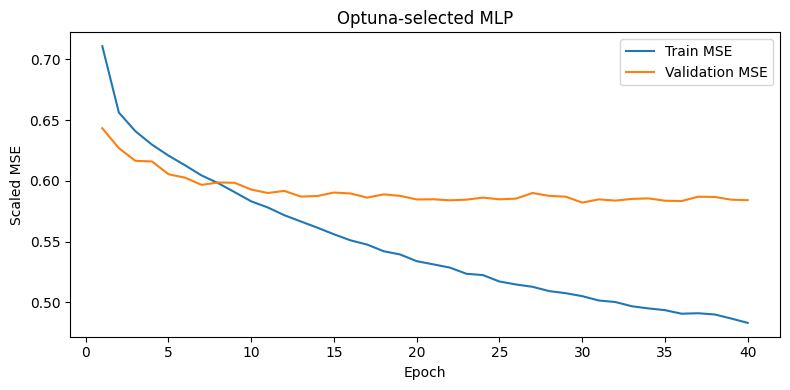

In [25]:
best_params = study.best_params
optuna_hidden_dims = build_hidden_dims(
    best_params['base_width'],
    best_params['depth'],
)
optuna_batch_size = best_params['batch_size']

optuna_train_loader = make_loader(
    train_dataset,
    optuna_batch_size,
    True,
)
optuna_valid_loader = make_loader(
    valid_dataset,
    optuna_batch_size,
    False,
)

torch.manual_seed(RANDOM_STATE)
optuna_model = RegressionMLP(
    90,
    optuna_hidden_dims,
    'relu',
    dropout_p=best_params['dropout_p'],
).to(device)

optuna_optimizer = torch.optim.AdamW(
    optuna_model.parameters(),
    lr=best_params['learning_rate'],
    weight_decay=best_params['weight_decay'],
)

optuna_result = fit_model(
    optuna_model,
    optuna_train_loader,
    optuna_valid_loader,
    optuna_optimizer,
    criterion,
    device,
    FINAL_EPOCHS,
)

optuna_val_mse = min(optuna_result.validation_loss_history)
optuna_val_rmse = scaled_mse_to_rmse_years(optuna_val_mse)

print('Optuna-selected architecture:', optuna_hidden_dims)
print('Best epoch:', optuna_result.best_epoch)
print('Validation MSE:', round(optuna_val_mse, 6))
print('Validation RMSE (years):', round(optuna_val_rmse, 3))
plot_training_history(optuna_result, 'Optuna-selected MLP')

## 13. Validation-based final model selection

In [26]:
fine_tune_val_mse = min(fine_tune_result.validation_loss_history)
fine_tune_val_rmse = scaled_mse_to_rmse_years(fine_tune_val_mse)

candidate_summary = pd.DataFrame([
    {
        'candidate': 'Optuna-selected MLP',
        'validation_mse': optuna_val_mse,
        'validation_rmse_years': optuna_val_rmse,
    },
    {
        'candidate': 'Fine-tuned auxiliary-pretrained model',
        'validation_mse': fine_tune_val_mse,
        'validation_rmse_years': fine_tune_val_rmse,
    },
]).sort_values('validation_rmse_years').reset_index(drop=True)

display(candidate_summary)

selected_candidate = candidate_summary.loc[0, 'candidate']

if selected_candidate == 'Optuna-selected MLP':
    final_model = copy.deepcopy(optuna_model).to(device)
    final_model_type = 'regression_mlp'
    final_hyperparameters = {
        'hidden_dims': optuna_hidden_dims,
        'dropout_p': best_params['dropout_p'],
        'learning_rate': best_params['learning_rate'],
        'weight_decay': best_params['weight_decay'],
        'batch_size': optuna_batch_size,
    }
    final_validation_mse = optuna_val_mse
    final_best_epoch = optuna_result.best_epoch
else:
    final_model = copy.deepcopy(fine_tuned_model).to(device)
    final_model_type = 'pretrained_regressor'
    final_hyperparameters = {
        'representation_dim': REPRESENTATION_DIM,
        'fine_tune_learning_rate': 1e-4,
        'weight_decay': 1e-2,
        'batch_size': BATCH_SIZE,
    }
    final_validation_mse = fine_tune_val_mse
    final_best_epoch = fine_tune_result.best_epoch

final_validation_rmse_years = scaled_mse_to_rmse_years(final_validation_mse)

print('SELECTED FINAL CANDIDATE:', selected_candidate)
print('Validation RMSE (years):', round(final_validation_rmse_years, 3))
print('Best epoch:', final_best_epoch)

,candidate,validation_mse,validation_rmse_years
0,Fine-tuned auxiliary-pretrained model,0.580401,8.336060
1,Optuna-selected MLP,0.582009,8.347603


SELECTED FINAL CANDIDATE: Fine-tuned auxiliary-pretrained model
Validation RMSE (years): 8.336
Best epoch: 30


### Final validation-based model selection

After full retraining, the Optuna-selected MLP reached **8.35 years validation RMSE**, while the fine-tuned auxiliary-pretrained model reached **8.34 years**.

The difference is small, but the selection rule was defined before opening the official test set, so the fine-tuned model is retained as the final candidate. No test-set result is used to revisit this decision.

## 14. Save and restore the selected checkpoint

In [27]:
CHECKPOINT_DIR = Path('artifacts')
CHECKPOINT_DIR.mkdir(exist_ok=True)
checkpoint_path = CHECKPOINT_DIR / 'year_prediction_final_checkpoint.pt'

checkpoint = {
    'model_type': final_model_type,
    'model_state_dict': final_model.state_dict(),
    'hyperparameters': final_hyperparameters,
    'best_epoch': final_best_epoch,
    'validation_mse': final_validation_mse,
    'validation_rmse_years': final_validation_rmse_years,
    'x_scaler_mean': x_scaler.mean_,
    'x_scaler_scale': x_scaler.scale_,
    'y_scaler_mean': y_scaler.mean_,
    'y_scaler_scale': y_scaler.scale_,
}

torch.save(checkpoint, checkpoint_path)
print('Checkpoint saved to:', checkpoint_path)

Checkpoint saved to: artifacts\year_prediction_final_checkpoint.pt


In [28]:
loaded_checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False,
)

if loaded_checkpoint['model_type'] == 'regression_mlp':
    hp = loaded_checkpoint['hyperparameters']
    restored_model = RegressionMLP(
        90,
        hp['hidden_dims'],
        'relu',
        dropout_p=hp['dropout_p'],
    ).to(device)
elif loaded_checkpoint['model_type'] == 'pretrained_regressor':
    hp = loaded_checkpoint['hyperparameters']
    restored_model = YearRegressorFromPretrained(
        AudioFeatureExtractor(90, hp['representation_dim']),
        hp['representation_dim'],
    ).to(device)
else:
    raise ValueError(f"Unknown model_type: {loaded_checkpoint['model_type']}")

restored_model.load_state_dict(loaded_checkpoint['model_state_dict'])
restored_model.eval()

print('Checkpoint restored successfully.')
print('Model type:', loaded_checkpoint['model_type'])
print('Validation RMSE (years):', round(loaded_checkpoint['validation_rmse_years'], 3))

Checkpoint restored successfully.
Model type: pretrained_regressor
Validation RMSE (years): 8.336


## 15. Official test evaluation

In [29]:
# The official test set is evaluated only after all model-selection decisions above.
test_pred_years, test_true_years = predict_years(
    restored_model,
    test_loader,
    device,
)

test_residuals = test_true_years - test_pred_years
test_absolute_errors = np.abs(test_residuals)

test_mae = float(np.mean(test_absolute_errors))
test_rmse = float(np.sqrt(np.mean(test_residuals ** 2)))

print('=' * 60)
print('OFFICIAL TEST RESULTS')
print('=' * 60)
print(f'N:    {len(test_true_years):,}')
print(f'MAE:  {test_mae:.3f} years')
print(f'RMSE: {test_rmse:.3f} years')

OFFICIAL TEST RESULTS
N:    51,630
MAE:  5.880 years
RMSE: 8.718 years


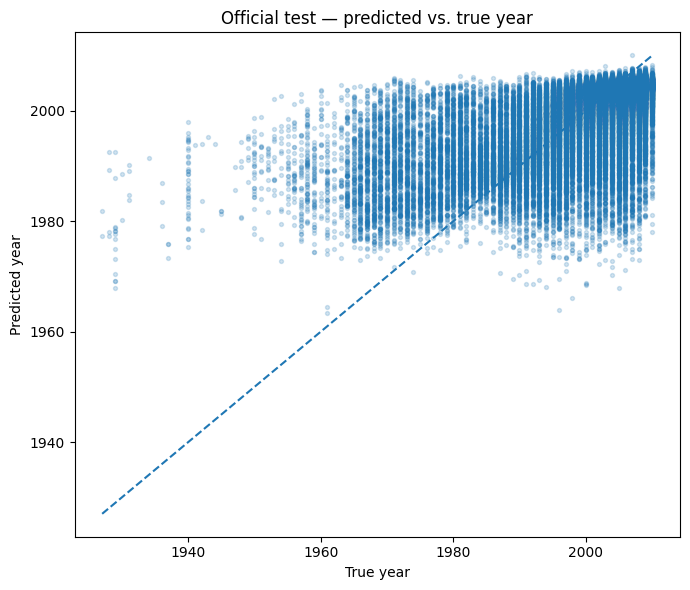

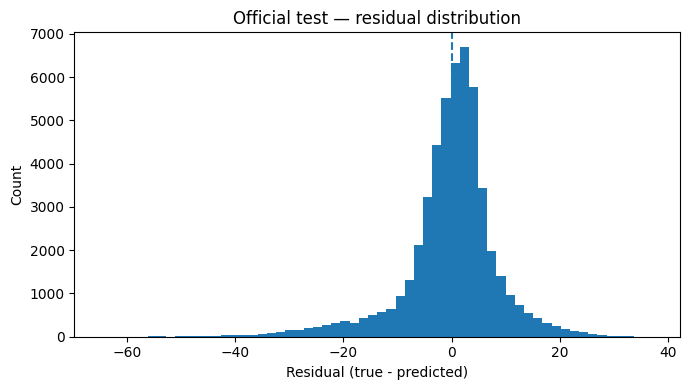

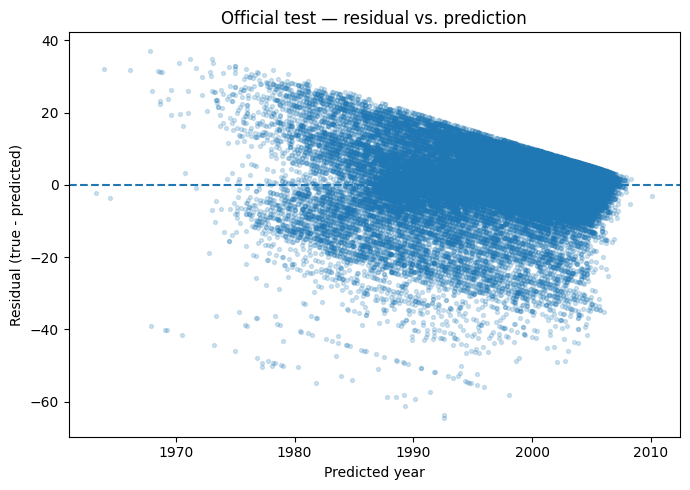

In [30]:
plt.figure(figsize=(7, 6))
plt.scatter(test_true_years, test_pred_years, alpha=0.20, s=8)
min_year = min(test_true_years.min(), test_pred_years.min())
max_year = max(test_true_years.max(), test_pred_years.max())
plt.plot([min_year, max_year], [min_year, max_year], linestyle='--')
plt.xlabel('True year')
plt.ylabel('Predicted year')
plt.title('Official test — predicted vs. true year')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(test_residuals, bins=60)
plt.axvline(0, linestyle='--')
plt.xlabel('Residual (true - predicted)')
plt.ylabel('Count')
plt.title('Official test — residual distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(test_pred_years, test_residuals, alpha=0.20, s=8)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted year')
plt.ylabel('Residual (true - predicted)')
plt.title('Official test — residual vs. prediction')
plt.tight_layout()
plt.show()

In [31]:
test_results_df = pd.DataFrame({
    'true_year': test_true_years,
    'predicted_year': test_pred_years,
})
test_results_df['residual'] = (
    test_results_df['true_year'] - test_results_df['predicted_year']
)
test_results_df['absolute_error'] = test_results_df['residual'].abs()
test_results_df['squared_error'] = test_results_df['residual'] ** 2
test_results_df['decade'] = (
    test_results_df['true_year'] // 10 * 10
).astype(int)

decade_error = (
    test_results_df
    .groupby('decade')
    .agg(
        N=('true_year', 'size'),
        MAE=('absolute_error', 'mean'),
        MSE=('squared_error', 'mean'),
        MeanResidual=('residual', 'mean'),
    )
    .reset_index()
)
decade_error['RMSE'] = np.sqrt(decade_error.pop('MSE'))

print('TEST ERROR BY DECADE')
display(decade_error.round(3))

TEST ERROR BY DECADE


,decade,N,MAE,MeanResidual,RMSE
0,1920,20,49.937000,-49.937000,50.469002
1,1930,13,49.706001,-49.706001,50.312000
2,1940,61,45.368999,-45.368999,45.806000
3,1950,275,32.797001,-32.797001,33.527000
4,1960,1166,22.174000,-22.174000,23.382000
5,1970,2396,15.651000,-15.636000,17.360001
6,1980,4201,7.226000,-6.537000,9.119000
7,1990,12580,4.711000,-1.115000,5.898000
8,2000,29885,4.338000,3.495000,6.296000
9,2010,1033,7.317000,7.317000,8.324000


### Official-test error analysis

The selected model obtains **5.88 years MAE** and **8.72 years RMSE** on all 51,630 official test songs. The noticeably larger RMSE shows that a minority of large errors contributes substantially to squared error.

Performance is strongly dependent on release decade:

- the 1990s achieve approximately **4.71 MAE / 5.90 RMSE**;
- the 2000s achieve approximately **4.34 MAE / 6.30 RMSE**;
- the 1980s rise to roughly **7.23 MAE / 9.12 RMSE**;
- errors grow rapidly for older decades.

The residual sign reveals a clear regression-to-density pattern. For historical songs, mean residuals are strongly negative, meaning the model predicts years that are too recent. For the 2000s and 2010s, mean residuals become positive, meaning predictions are pulled toward earlier years. In other words, predictions are compressed toward the densely represented late-1990s/2000s region of the target distribution.

The extreme early-decade metrics should be interpreted cautiously because those bins contain very few test samples—for example, only 20 songs from the 1920s and 13 from the 1930s. Even so, the broader deterioration from the 1960s through the 1980s is consistent with the severe target imbalance observed in training.

The official-test RMSE is also modestly worse than the validation RMSE. A plausible contributor is that the internal validation split is random within the official training partition, whereas the official test split explicitly separates artists. Because artist identifiers are not provided in the feature matrix, this hypothesis cannot be tested directly inside this notebook.

## 16. Execution summary

In [32]:
print('DATASET')
print('  Full rows:', f'{len(df):,}')
print('  Train rows used:', f'{len(train_df):,}')
print('  Validation rows:', f'{len(valid_df):,}')
print('  Official test rows:', f'{len(test_df):,}')

print('\nTRAINING ABLATIONS')
display(experiment_summary)

print('\nTRANSFER LEARNING')
display(transfer_comparison)

print('\nFINAL CANDIDATES')
display(candidate_summary)

print('\nSELECTED MODEL')
print(' ', selected_candidate)
print('  Validation RMSE:', round(final_validation_rmse_years, 3), 'years')

print('\nOFFICIAL TEST')
print('  MAE:', round(test_mae, 3), 'years')
print('  RMSE:', round(test_rmse, 3), 'years')

DATASET
  Full rows: 515,345
  Train rows used: 417,343
  Validation rows: 46,372
  Official test rows: 51,630

TRAINING ABLATIONS


,experiment,parameters,best_epoch,validation_mse,validation_rmse_years,training_seconds
0,BatchNorm + AdamW + Dropout,65409,30,0.585784,8.374624,199.082378
1,He init + AdamW + Dropout,64513,29,0.592798,8.424618,195.085585
2,Multi-branch MLP,26641,16,0.624087,8.644091,171.532660
3,Baseline MLP — SGD,64513,30,0.626107,8.658066,171.114638



TRANSFER LEARNING


,model,best_epoch,validation_mse,validation_rmse_years
0,Fine-tuned auxiliary pretraining,30,0.580401,8.336060
1,Regression from scratch,27,0.586570,8.380246
2,Frozen auxiliary pretraining,23,0.612404,8.562801



FINAL CANDIDATES


,candidate,validation_mse,validation_rmse_years
0,Fine-tuned auxiliary-pretrained model,0.580401,8.336060
1,Optuna-selected MLP,0.582009,8.347603



SELECTED MODEL
  Fine-tuned auxiliary-pretrained model
  Validation RMSE: 8.336 years

OFFICIAL TEST
  MAE: 5.88 years
  RMSE: 8.718 years


## Results and conclusions

The project trained neural regressors on more than half a million songs while preserving UCI's locked artist-aware test partition.

### Main findings

- A plain SGD MLP established a validation RMSE of roughly **8.66 years**.
- Optimization and regularization changes mattered more than manually separating timbre means and covariance features. The best retained ablation, **BatchNorm + AdamW + dropout**, reduced validation RMSE to about **8.37 years**.
- The multi-branch architecture was parameter-efficient but did not improve predictive performance.
- Auxiliary decade pretraining was not useful when the learned feature extractor was frozen. Once the full network was fine-tuned at a lower learning rate, however, validation RMSE improved to **8.34 years**, slightly outperforming both the same architecture trained from scratch and the Optuna-selected MLP.
- The final model was chosen using validation performance only and then evaluated once on the official test set.
- Official test performance was **MAE = 5.88 years** and **RMSE = 8.72 years**.
- Error is highly non-uniform across the target distribution. The model performs best in the densely represented 1990s/2000s and increasingly pulls sparse historical examples toward more recent years.
- The gap between MAE and RMSE confirms that a subset of large errors remains important even when the typical absolute error is moderate.

### Limitations

The strongest limitation is target imbalance: early decades are extremely underrepresented. A second limitation is the internal validation design. UCI's official test partition is artist-aware, but artist IDs are not available in the benchmark feature matrix, so the internal random validation split cannot reproduce that constraint.

Future work could evaluate target-aware sampling or loss weighting, obtain artist metadata for group-aware internal validation, or compare the MLP representation against architectures designed specifically for structured audio embeddings. These extensions were intentionally left outside the locked-test model-selection process.